# Stock Change Distribution

Explore the distribution of daily changes in a stock price.

## What's in the data

`prices` is the **daily closing level of the S&P 500 index** (in points).

We study the **daily percent change**

$$\text{change}_t = 100 \times \left(\frac{\text{price}_t}{\text{price}_{t-1}} - 1\right)$$

i.e. how far the index moved from one trading day's close to the next, as a
percentage. Up days are positive, down days negative. (The price *ratio* is
always positive, so this is always well defined.)

**Question:** is that day-to-day movement well described by a normal
(bell-curve) distribution?

- **Left panel:** in the middle, the bell curve fits fine.
- **Right panel:** same histogram, but with a **logarithmic vertical axis** so
  we can see the rare large moves. The bell curve predicts that crashes and
  melt-ups essentially never happen; the data shows they happen regularly.

In [9]:
# Colab doesn't ship yfinance. %pip installs into whichever kernel is running,
# so this works on Colab and is a harmless no-op locally.
%pip install -q yfinance

Note: you may need to restart the kernel to use updated packages.


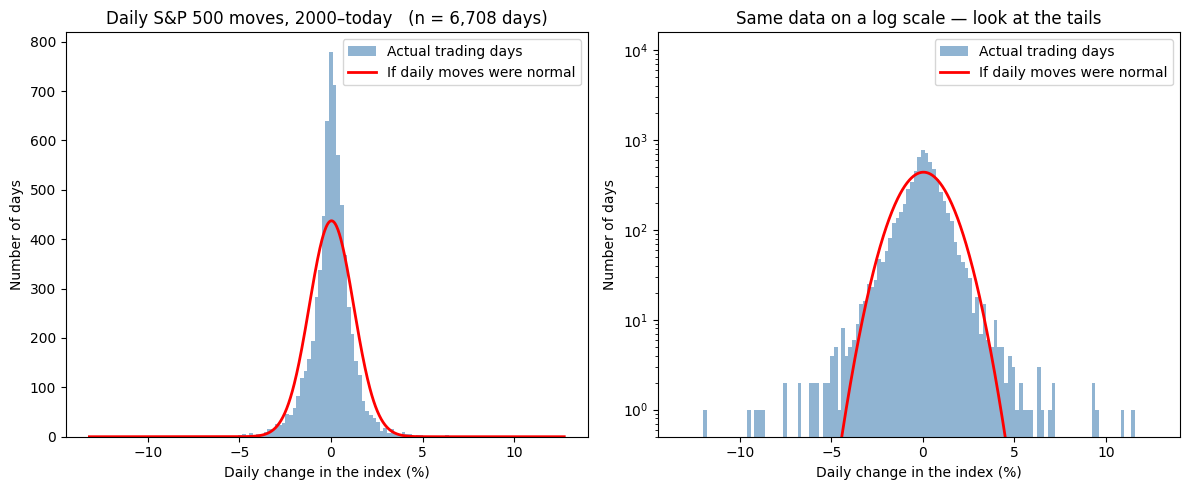

          move |  actual days |  normal predicts
------------------------------------------------
  more than  3.6% |          105 |            18.11
  more than  4.8% |           45 |             0.42
  more than  6.1% |           23 |             0.00

Biggest one-day drop:  -12.0%  on 2020-03-16
Biggest one-day gain:   11.6%  on 2008-10-13
Excess kurtosis (0 = normal, higher = fatter tails): 10.5


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

# --- Data ---------------------------------------------------------------
ticker = "^GSPC"                     # S&P 500  (use "^DJI" for the Dow Jones)
data = yf.download(ticker, start="2000-01-01", auto_adjust=True,
                   progress=False, multi_level_index=False)

prices = data["Close"].dropna()     # daily closing index level, in points

# Daily percent change from the previous close. prices/prices.shift(1) is
# always positive, so this is always defined; it is simply negative on down days.
change = (prices.pct_change() * 100).dropna()
change.name = "Daily % change"

# --- Best-fit normal ("bell curve") with the same mean and spread ------
mu, sigma = stats.norm.fit(change)
n = len(change)

# --- Figure -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.linspace(change.min(), change.max(), 120)
binwidth = bins[1] - bins[0]
xx = np.linspace(change.min() * 1.1, change.max() * 1.1, 1000)
normal_days = stats.norm.pdf(xx, mu, sigma) * n * binwidth   # expected #days per bin

for ax in axes:
    ax.hist(change, bins=bins, color="steelblue", alpha=0.6, label="Actual trading days")
    ax.plot(xx, normal_days, "r-", lw=2, label="If daily moves were normal")
    ax.set_xlabel("Daily change in the index (%)")
    ax.set_ylabel("Number of days")
    ax.legend()

axes[0].set_title(f"Daily S&P 500 moves, 2000–today   (n = {n:,} days)")

axes[1].set_yscale("log")
axes[1].set_ylim(bottom=0.5)
axes[1].set_title("Same data on a log scale — look at the tails")

plt.tight_layout()
plt.show()

# --- How often do big moves actually happen vs. the normal prediction? ---
print(f"{'move':>14} | {'actual days':>12} | {'normal predicts':>16}")
print("-" * 48)
for k in (3, 4, 5):
    cutoff = k * sigma
    actual = int(np.sum(np.abs(change - mu) > cutoff))
    predicted = n * 2 * (1 - stats.norm.cdf(k))
    print(f"  more than {cutoff:4.1f}% | {actual:>12} | {predicted:>16.2f}")

print(f"\nBiggest one-day drop: {change.min():6.1f}%  on {change.idxmin().date()}")
print(f"Biggest one-day gain: {change.max():6.1f}%  on {change.idxmax().date()}")
print(f"Excess kurtosis (0 = normal, higher = fatter tails): {stats.kurtosis(change):.1f}")